# Проект
---
---

In [1]:
import os
import re

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

---
## 1. Обработка Данных

План1:
- 1 сем: ОМА, ЛАиАГ
- 2 сем: МА, ДУ,
- 3 сем: СРМА, ДМ
- 4 сем: ТВиМС

План2:
- 1 сем: ОМА, ЛАиАГ
- 2 сем: МА, ДУ, ДМ
- 3 сем: СРМА, ТВиМС

Приведем данные к следующему в формату - каждая строка dataframe'а будет представлять одну конкретную оценка студента за одно конкретное мероприятие.

Столбцы в `final_df`:
- `План` (int): `1`/`2`
- `Сем` (int): `1`/`2`/`3`/`4`
- `Дисц` (str): ... (название дисциплины)
- `КМ` (str): ... (контрольное мероприятие)
- `НБ` (float): нормированный балл студента за данное КМ
- `СБ` (float): об этом позже: `СБ = НБ * ПКБП`


In [2]:
overall_df_parts = []

Сначала обрабатоем все файлы - потом объединими их.

#### Обработка файла "`Дисц 1 и 2 семестра ПИН_31-36 22-23.xlsx`"

In [ ]:
filepath = os.path.join(
    'data',
    'raw'
    'Данные по Плану 1 ПИН',
    'Дисц 1 и 2 семестра  ПИН_31-36 22-23.xlsx'
)

In [5]:
df_raw = pd.read_excel(filepath, header=0).dropna()

print(f'Исходная таблица "{filepath}":')
display(df_raw.head())

Исходная таблица "data\Данные по Плану 1 ПИН\Дисц 1 и 2 семестра  ПИН_31-36 22-23.xlsx":


,ДУ_а1,ДУ_а2,ДУ_бдз2,ДУ_зачет,ДУ_итог,ДУ_к1,ДУ_кр2,ДУ_кр3,МА_а2,МА_а3,...,АиГ_итог,АиГ_к1,АиГ_кр1,АиГ_кр2,АиГ_кр3,АиГ_экз,ДУ_бдз1,ДУ_кр1,МА_ср1,оМА_кр1
0,0.286,0.834,0.750,0.933333,0.7635,0.9,0.625,1.0,0.125,0.25,...,0.53,0.466667,0.5,0.6,0.5,0.500,0.95,0.000,0.50,0.5000
1,0.858,0.922,1.000,0.800000,0.8873,1.0,0.750,1.0,0.200,0.25,...,0.62,1.000000,1.0,0.8,0.5,0.375,1.00,0.833,0.25,0.6250
2,0.892,1.000,1.000,0.833333,0.9446,1.0,1.000,1.0,1.000,1.00,...,0.72,0.666667,0.5,1.0,1.0,0.625,1.00,1.000,1.00,0.5000
3,0.892,1.000,0.714,0.700000,0.8703,1.0,1.000,0.8,1.000,1.00,...,0.78,0.666667,0.7,0.8,1.0,0.750,1.00,1.000,0.25,0.9375
4,1.000,1.000,1.000,0.900000,0.9700,1.0,1.000,1.0,1.000,1.00,...,0.92,0.666667,1.0,1.0,1.0,1.000,1.00,1.000,0.25,0.8125


In [6]:
disc_name_correct = {
    'ДУ': 'ДУ', 'МА': 'МА',
    'АиГ': 'ЛАиАГ',
    'AиГ': 'ЛАиАГ',  # Здесь в 'АиГ' буквы 'А' - английская, такой вариант встречается в таблице.
    'оМА': 'ОМА',
}

def define_correct_disc(raw_disc):
    return disc_name_correct[raw_disc.strip()]

def define_sem(correct_disc):
    if correct_disc in ['ОМА', 'ЛАиАГ']:
        return 1
    if correct_disc in ['МА', 'ДУ']:
        return 2
    return np.nan

In [7]:
melted_df_p1s12 = df_raw.melt(var_name='raw_header', value_name='НБ')
print(f'Raw melted df:')
display(melted_df_p1s12.head())

header_split = melted_df_p1s12['raw_header'].str.split('_', n=1, expand=True)
melted_df_p1s12['raw_disc'] = header_split[0]
melted_df_p1s12['КМ'] = header_split[1]

melted_df_p1s12['Дисц'] = melted_df_p1s12['raw_disc'].apply(define_correct_disc)
melted_df_p1s12['Сем'] = melted_df_p1s12['Дисц'].apply(define_sem)

melted_df_p1s12['План'] = 1
melted_df_p1s12['СБ'] = 0.0

processed_df_p1s12 = melted_df_p1s12[['План', 'Сем', 'Дисц', 'КМ', 'НБ', 'СБ']].copy()

processed_df_p1s12['План'] = processed_df_p1s12['План'].astype(int)
processed_df_p1s12['Сем'] = processed_df_p1s12['Сем'].astype(int)

overall_df_parts.append(processed_df_p1s12.copy())
overall_df_parts[-1].info()
display(overall_df_parts[-1])

Raw melted df:


,raw_header,НБ
0,ДУ_а1,0.286
1,ДУ_а1,0.858
2,ДУ_а1,0.892
3,ДУ_а1,0.892
4,ДУ_а1,1.000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   План    6435 non-null   int32  
 1   Сем     6435 non-null   int32  
 2   Дисц    6435 non-null   object 
 3   КМ      6435 non-null   object 
 4   НБ      6435 non-null   float64
 5   СБ      6435 non-null   float64
dtypes: float64(2), int32(2), object(2)
memory usage: 251.5+ KB


,План,Сем,Дисц,КМ,НБ,СБ
0,1,2,ДУ,а1,0.2860,0.0
1,1,2,ДУ,а1,0.8580,0.0
2,1,2,ДУ,а1,0.8920,0.0
3,1,2,ДУ,а1,0.8920,0.0
4,1,2,ДУ,а1,1.0000,0.0
...,...,...,...,...,...,...
6430,1,1,ОМА,кр1,0.6875,0.0
6431,1,1,ОМА,кр1,0.8125,0.0
6432,1,1,ОМА,кр1,0.5000,0.0
6433,1,1,ОМА,кр1,0.0000,0.0


#### Обработка остальных файлов

По структуре остальные файлы довольно схожи, поскольку представлют собой журнал оценок. Нас интересуют в этих журналах только наименования КМ и нормализованные баллы, а поскольку баллы там ненормализованны, то нас интересует макс. баллы и просто баллы студентов.
А потому определим функци, которая будет приводить в нужный нам формат журнальные таблицы.

In [ ]:
def parse_raw_journal_df(
        df_raw: pd.DataFrame,
        km_row_idx: int,
        km_end_col_idx: int,
        plan: int,
        semester: int,
        discipline: str,
        max_scores_row_idx: int | None = None,
        student_data_start_row_idx: int | None = None,
) -> pd.DataFrame:
    """
    Универсальная функция для парсинга журналов оценок.

    Args:
        df_raw: Сырой DataFrame, загруженный из Excel.
        km_row_idx: Индекс строки с короткими названиями КМ.
        km_end_col_idx: Индекс колонки, до которой идут КМ.
        max_scores_row_idx: Индекс строки с максимальными баллами. По умолчанию km_row_idx + 1.
        student_data_start_row_idx: Индекс строки начала данных студентов. По умолчанию km_row_idx + 2.
        km_weeks_row_idx: Индекс строки с неделями КМ (опционально).
        plan: Значение для колонки 'План'.
        semester: Значение для колонки 'Сем'.
        discipline: Значение для колонки 'Дисц'.

    Returns:
        Обработанный DataFrame в "длинном" формате.
    """
    max_scores_row_idx = max_scores_row_idx or (km_row_idx + 1)
    student_data_start_row_idx = student_data_start_row_idx or (km_row_idx + 2)

    # 1. Извлечение КМ и макс. баллов
    raw_km_names = list(df_raw.iloc[km_row_idx, :km_end_col_idx].astype(str))

    km_names = []
    for km in raw_km_names:
        if km.strip().lower() == 'итог':
            km_names.append('Экз')
        else:
            km_names.append(km)
    km_names.append('Итог')

    num_kms = len(km_names)
    max_scrores_series = df_raw.iloc[max_scores_row_idx, :num_kms]
    max_scrores_list = [
        float(str(score).replace(',', '.').strip())
        for score in max_scrores_series
    ]
    if num_kms != len(max_scrores_list):
        raise ValueError('Кол-во КМ\'ов не совпадает с кол-вом макс. баллов.')

    km2maxscore = dict(zip(km_names, max_scrores_list))

    # 2. Извелечение баллов студентов
    student_scores_raw_df = df_raw.iloc[student_data_start_row_idx:, :num_kms].copy()
    student_scores_raw_df.columns = km_names
    student_scores_raw_df.dropna(how='all', inplace=True)
    student_scores_raw_df.reset_index(drop=True, inplace=True)

    # 3. Нормализация
    processed_scores_df = pd.DataFrame(index=student_scores_raw_df.index)
    for km in km_names:
        score_str = (student_scores_raw_df[km].astype(str)
                     .str.lower().replace(',', '.'))
        score_float = pd.to_numeric(score_str, errors='coerce').clip(upper=km2maxscore[km])
        normalized = score_float / km2maxscore[km]
        processed_scores_df[km] = normalized

    # 4. В длинный формат
    melted_df = processed_scores_df.melt(var_name='КМ', value_name='НБ')
    melted_df.dropna(subset=['НБ'], inplace=True)

    melted_df['План'] = plan
    melted_df['Сем'] = semester
    melted_df['Дисц'] = discipline
    melted_df['СБ'] = 0.0

    # 5. Завершающий шаг
    final_columns_order = ['План', 'Сем', 'Дисц', 'КМ', 'НБ', 'СБ']
    processed_df = melted_df[final_columns_order].copy()
    processed_df['План'] = processed_df['План'].astype(int)
    processed_df['Сем'] = processed_df['Сем'].astype(int)

    return processed_df

In [ ]:
def find_km_indices(df_raw):
    km_row_idx = None  # Индекс строки в которой есть "КР.1"
    km_end_col_idx = None  # Индекс первого значения в той строке, которое NAN

    for idx, row in df_raw.iterrows():
        if row.astype(str).eq('КР.1').any():
            km_row_idx = idx
            break

    if km_row_idx is None:
        raise ValueError('Не удалось найти КМ строку в таблице')

    km_row_values = df_raw.iloc[km_row_idx]
    for col_idx, value in enumerate(km_row_values):
        if pd.isna(value) or str(value).strip() == '':
            km_end_col_idx = col_idx
            break

    if km_end_col_idx is None:
        raise ValueError('Не удалось найти конец КМ строки')

    return km_row_idx, km_end_col_idx

In [10]:
datafiles = [
    [  # План 1
        "ДМ ПИН-31_36_ 3 семестр 23_24 .xlsx",
        "СРМА ПИН-31-34 3 сем 23_24 .xlsx",
        "ТВиМС ПИН-31-36 4 сем 23_24 .xlsx",
    ],
    [  # План 2
        "АиГ ПИН-21-27 1 сем 23-24.xlsx",
        "ДМ ПИН-21-27 2 сем 23-24.xlsx",
        "ДУ ПИН-21-27 2 сем 23-24.xlsx",
        "МА ПИН-21-27 2 сем 23-24.xlsx",
        "ОМА ПИН-21-27 1 сем 23-24.xlsx",
        "СРМА ПИН-21-27 3 сем 24-25.xlsx",
        "ТВиМС ПИН-21-27 3 сем 24-25.xlsx",
    ]
]

disc_corrector = {
    'АиГ': 'ЛАиАГ'
}

In [ ]:
if len(overall_df_parts) > 1:
    overall_df_parts = [overall_df_parts[0]]


for plan_idx in range(len(datafiles)):
    for filename in datafiles[plan_idx]:
        df_raw = pd.read_excel(os.path.join(
            'data',
            f'Данные по Плану {plan_idx+1} ПИН',
            filename
        ), header=None)

        filename_splitting = filename.split()

        disc_name = filename_splitting[0]
        if disc_name in disc_corrector:
            disc_name = disc_corrector[disc_name]

        sem_idx = next((
            i for i, v in enumerate(filename_splitting)
            if v.startswith('сем')
        ), None) - 1
        sem = int(filename_splitting[sem_idx])

        km_row_idx, km_end_col_idx = find_km_indices(df_raw)

        overall_df_parts.append(parse_raw_journal_df(
            df_raw=df_raw,
            km_row_idx=km_row_idx,
            km_end_col_idx=km_end_col_idx,
            plan=plan_idx+1,
            semester=sem,
            discipline=disc_name
        ))

In [12]:
unformmatted_overall_df = pd.concat(overall_df_parts, ignore_index=True)

unformmatted_overall_df.info()
display(unformmatted_overall_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18195 entries, 0 to 18194
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   План    18195 non-null  int32  
 1   Сем     18195 non-null  int32  
 2   Дисц    18195 non-null  object 
 3   КМ      18195 non-null  object 
 4   НБ      18195 non-null  float64
 5   СБ      18195 non-null  float64
dtypes: float64(2), int32(2), object(2)
memory usage: 710.9+ KB


,План,Сем,Дисц,КМ,НБ,СБ
0,1,2,ДУ,а1,0.2860,0.0
1,1,2,ДУ,а1,0.8580,0.0
2,1,2,ДУ,а1,0.8920,0.0
3,1,2,ДУ,а1,0.8920,0.0
4,1,2,ДУ,а1,1.0000,0.0
...,...,...,...,...,...,...
18190,2,3,ТВиМС,Итог,0.5000,0.0
18191,2,3,ТВиМС,Итог,0.5329,0.0
18192,2,3,ТВиМС,Итог,0.0000,0.0
18193,2,3,ТВиМС,Итог,0.5193,0.0


In [13]:
_unique_unformatted_disc = set(unformmatted_overall_df['Дисц'])

print(len(_unique_unformatted_disc))
print(_unique_unformatted_disc)

7
{'МА', 'ЛАиАГ', 'ОМА', 'ДУ', 'СРМА', 'ДМ', 'ТВиМС'}


In [14]:
_unique_unformatted_km = set(unformmatted_overall_df['КМ'])

print(len(_unique_unformatted_km))
print(_unique_unformatted_km)

40
{'бдз4', 'КР.3', 'А.2', 'экз', 'кр3', 'к1', 'зачет', 'КР.1', 'А/П.1', 'А.1', 'К.2', 'а4', 'БДЗ.3', 'итог', 'бдз2', 'БДЗ.2', 'З.1', 'БДЗ.1', 'Экз', 'бдз1', 'кр2', 'Т.1', 'СР.1', 'ДЗ.1', 'А.3', 'БДЗ.4', 'бдз3 ', 'а1', 'ДЗ.2', 'А/П.2', 'А/П.3', 'КР.2', 'ср1', 'а2', 'Итог', 'а3', 'кр1', 'бдз3', 'К.1', 'акт'}


Приведем названия КМ к общему формату: добавим колонку `"КМ.т"` (str) для типа КМ и `"КМ.н"` (int) для номера КМ этого типа.

In [15]:
_KM_SANITIZE_RULES = {
    re.compile(r'(акт|а/п)(\.?)(\d*)', re.IGNORECASE): lambda m: ('А', int(m.group(3) or '1')),
    # аКт -> А.1; Акт8 -> А.8; а/п19 -> А.19; А/П.1 -> А.1
    re.compile(r'дз(\.?)(\d*)', re.IGNORECASE): lambda m: ('БДЗ', int(m.group(2) or '1')),
    # дЗ -> БДЗ.1; ДЗ.7 -> БДЗ.7
    re.compile(r'(а|т|бдз|ср|кр|к)(\.?)(\d*)', re.IGNORECASE): lambda m: (m.group(1).upper(), int(m.group(3) or '1')),
    # бдз123 -> БДЗ.123; СР.7 -> СР.7
    re.compile(r'(з|зачет|экз|экзамен)(\.1)?', re.IGNORECASE): lambda m: ('Экз', 1),
    re.compile(r'итог', re.IGNORECASE): lambda m: ('Итог', 1)
}


def km_sanitize(string: str) -> tuple[str, int]:
    string = string.strip().lower()
    for pattern, replacement in _KM_SANITIZE_RULES.items():
        match = re.fullmatch(pattern, string)
        if match is not None:
            return replacement(match)
    raise ValueError(f'Не нашлось подходящего шаблона для строки "{string}"')

In [16]:
km_series = unformmatted_overall_df['КМ'].apply(km_sanitize)
km_series

0           (А, 1)
1           (А, 1)
2           (А, 1)
3           (А, 1)
4           (А, 1)
           ...    
18190    (Итог, 1)
18191    (Итог, 1)
18192    (Итог, 1)
18193    (Итог, 1)
18194    (Итог, 1)
Name: КМ, Length: 18195, dtype: object

In [17]:
overall_df = unformmatted_overall_df.copy()
overall_df[['КМ.т', 'КМ.н']] = pd.DataFrame(km_series.tolist(), index=overall_df.index)
overall_df = overall_df[['План', 'Сем', 'Дисц', 'КМ.т', 'КМ.н', 'НБ', 'СБ']]

display(overall_df)
overall_df.info()
display(overall_df.describe())

,План,Сем,Дисц,КМ.т,КМ.н,НБ,СБ
0,1,2,ДУ,А,1,0.2860,0.0
1,1,2,ДУ,А,1,0.8580,0.0
2,1,2,ДУ,А,1,0.8920,0.0
3,1,2,ДУ,А,1,0.8920,0.0
4,1,2,ДУ,А,1,1.0000,0.0
...,...,...,...,...,...,...,...
18190,2,3,ТВиМС,Итог,1,0.5000,0.0
18191,2,3,ТВиМС,Итог,1,0.5329,0.0
18192,2,3,ТВиМС,Итог,1,0.0000,0.0
18193,2,3,ТВиМС,Итог,1,0.5193,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18195 entries, 0 to 18194
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   План    18195 non-null  int32  
 1   Сем     18195 non-null  int32  
 2   Дисц    18195 non-null  object 
 3   КМ.т    18195 non-null  object 
 4   КМ.н    18195 non-null  int64  
 5   НБ      18195 non-null  float64
 6   СБ      18195 non-null  float64
dtypes: float64(2), int32(2), int64(1), object(2)
memory usage: 853.0+ KB


,План,Сем,КМ.н,НБ,СБ
count,18195.000000,18195.000000,18195.000000,18195.000000,18195.0
mean,1.523111,1.979720,1.596977,0.650054,0.0
std,0.499479,0.845213,0.804025,0.297656,0.0
min,1.000000,1.000000,1.000000,0.000000,0.0
25%,1.000000,1.000000,1.000000,0.500000,0.0
50%,2.000000,2.000000,1.000000,0.685714,0.0
75%,2.000000,3.000000,2.000000,0.916667,0.0
max,2.000000,4.000000,4.000000,1.000000,0.0


In [18]:
_unique_disc = set(overall_df['Дисц'])
_unique_km = set(overall_df['КМ.т'])

print(len(_unique_disc))
print(_unique_disc)
print()
print(len(_unique_km))
print(_unique_km)

7
{'МА', 'ЛАиАГ', 'ОМА', 'ДУ', 'СРМА', 'ДМ', 'ТВиМС'}

8
{'К', 'Итог', 'СР', 'Экз', 'БДЗ', 'А', 'КР', 'Т'}


Таким образом мы свели все имеющиеся данные в один DataFrame:

Каждая строка dataframe'а представляет одну конкретную оценка студента за одно конкретное КМ.

Столбцы в `final_df`:
- `План` (int): `1, 2`
- `Сем` (int): `1, 2, 3, 4`
- `Дисц` (str): `'ОМА', 'ЛАиАГ', 'МА', 'ДУ', 'ДМ', 'СРМА', 'ТВиМС'`
- `КМ.т` (str): тип КМ: `'А'` (активность), `'БДЗ'`, `'Т'` (тест), `'СР'`, `'КР'`, `'К'` (коллоквиум), `'Итог'` (экзмаен или зачет)
- `КМ.т` (int): номер КМ данного типа: нижняя граница = `1`, верхней нет, но в наших данных это `4`
- `НБ` (float): нормированный балл студента за данное КМ
- `СБ` (float): сбалансированный балл студента - НБ с учетом ПКБП (поправочного коэффициента базовой подготовки) - пока не заполнена.

In [19]:
final_df = overall_df[overall_df['КМ.т'] == 'Итог'][['План', 'Дисц', 'НБ', 'СБ']]
final_df

,План,Дисц,НБ,СБ
572,1,ДУ,0.7635,0.0
573,1,ДУ,0.8873,0.0
574,1,ДУ,0.9446,0.0
575,1,ДУ,0.8703,0.0
576,1,ДУ,0.9700,0.0
...,...,...,...,...
18190,2,ТВиМС,0.5000,0.0
18191,2,ТВиМС,0.5329,0.0
18192,2,ТВиМС,0.0000,0.0
18193,2,ТВиМС,0.5193,0.0


In [20]:
# Вместе с тем введем еще пару констант

DISC_TUPLE = ('ОМА', 'ЛАиАГ', 'МА', 'ДУ', 'ДМ', 'СРМА', 'ТВиМС')
# Отсортированный по семестрам кортеж дисциплин

KM_TUPLE = ('A', 'БДЗ', 'Т', 'СР', 'КР', 'К', 'Экз', 'Итог')
# Кортеж КМ

---
## 2. Подготовка и Первичный Обзор Данных

In [21]:
display(final_df)

,План,Дисц,НБ,СБ
572,1,ДУ,0.7635,0.0
573,1,ДУ,0.8873,0.0
574,1,ДУ,0.9446,0.0
575,1,ДУ,0.8703,0.0
576,1,ДУ,0.9700,0.0
...,...,...,...,...
18190,2,ТВиМС,0.5000,0.0
18191,2,ТВиМС,0.5329,0.0
18192,2,ТВиМС,0.0000,0.0
18193,2,ТВиМС,0.5193,0.0


In [22]:
# Если результат блока - True, то пропусков нет.
int(final_df.isnull().sum().sum()) == 0

True

In [23]:
final_df['НБ'].describe()

count    1888.000000
mean        0.572189
std         0.241238
min         0.000000
25%         0.500000
50%         0.580000
75%         0.740000
max         1.000000
Name: НБ, dtype: float64

In [24]:
print(list(final_df['НБ']))

[0.7635, 0.8873000000000001, 0.9445999999999999, 0.8703, 0.97, 0.8808, 0.9273, 0.5146000000000001, 0.6114999999999999, 0.9554, 0.9047, 1.0, 0.7957, 0.8809, 0.9353, 0.9042, 0.8987999999999999, 0.8808, 0.9415, 0.8787, 0.9351999999999999, 0.8706, 0.9344, 0.8693000000000001, 0.0286, 0.9139, 0.8883, 0.9111, 0.5979, 0.8629000000000001, 0.8682, 0.6181, 0.9301, 0.5143, 0.7805, 0.96, 0.31, 0.7879999999999999, 0.8801000000000001, 0.8673000000000001, 0.777, 0.8662000000000001, 0.8643000000000001, 0.5399, 0.7881, 0.5018, 0.7609, 0.8618000000000001, 0.966, 0.5191, 0.5133, 0.868, 0.55, 0.29, 0.01, 0.16, 0.14, 0.885, 0.05, 0.54, 0.905, 0.555, 0.52, 0.705, 0.01, 0.545, 0.13, 0.72, 0.555, 0.775, 0.06, 0.74, 0.21, 0.755, 0.755, 0.93, 0.61, 0.7, 0.0, 0.53, 0.965, 0.705, 0.16, 0.765, 0.56, 0.615, 0.915, 0.76, 0.76, 0.55, 0.19, 0.895, 0.74, 0.585, 0.73, 0.56, 0.53, 0.03, 0.885, 0.565, 0.93, 0.89, 0.2, 0.71, 0.29, 0.575, 0.71, 0.61, 0.7, 0.86, 0.94, 0.12, 0.705, 0.275, 0.515, 0.61, 0.745, 0.72, 0.64, 0.11, 

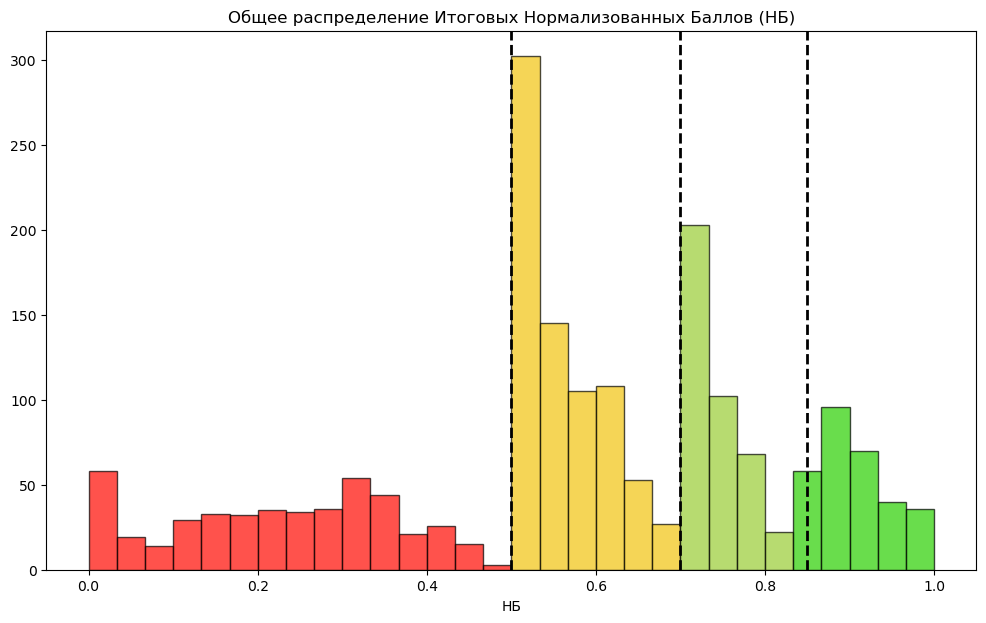

In [25]:
colors_zones = {
'Неудовл': "#FF0800",
'Удовл': "#F1C40F",
'Хор': "#99CC33",
'Отл': "#29CF00"
}

bound1 = 0.5
bound2 = 0.7
bound3 = 0.85


# sns.histplot(final_df['НБ'], kde=True, color='mediumblue')

# plt.axvline(x=0.5, color='r', label='Граница Неудовл/Удовл')
# plt.axvline(x=0.7, color='g', label='Граница Удовл/Хор')
# plt.axvline(x=0.85, color='b', label='Граница Хор/Отл')

# plt.title('Общее распределение Итоговых Нормализованных Баллов (НБ)')
# plt.xlabel('НБ')
# plt.legend()
# plt.show()

plt.figure(figsize=(12, 7))

counts, bin_edges, patches = plt.hist(final_df['НБ'], bins=30 ,color='lightgray', alpha=0.7, ec='gray')

for i, p in enumerate(patches):
    bin_center = (bin_edges[i] + bin_edges[i+1]) / 2
    if bin_center < bound1:
        p.set_facecolor(colors_zones['Неудовл'])
    elif bin_center < bound2:
        p.set_facecolor(colors_zones['Удовл'])
    elif bin_center < bound3:
        p.set_facecolor(colors_zones['Хор'])
    else:
        p.set_facecolor(colors_zones['Отл'])
    p.set_edgecolor('black')

line_color_boundary = 'black'
plt.axvline(bound1, color=line_color_boundary, ls='--', linewidth=2)
plt.axvline(bound2, color=line_color_boundary, ls='--', linewidth=2)
plt.axvline(bound3, color=line_color_boundary, ls='--', linewidth=2)

plt.title('Общее распределение Итоговых Нормализованных Баллов (НБ)')
plt.xlabel('НБ')
plt.show()


In [26]:
# TODO: опистаь диагрмму, на мой взгляд она интересная

Диаграмма представляет общее распределение нормализированных баллов. Хорошо видны пики диаграм, соответствующих НБ: 0.5, 0.7, 0.85 с последующим спадом. Это есть минимальные баллы для получения оценок 3, 4, и 5 соответсвенно. Данное распрделение хорошо согласуется с реальностью. Действительно, так как студенты получают оценку по пятибальной шкале, они стараются достичь именно таких баллов 

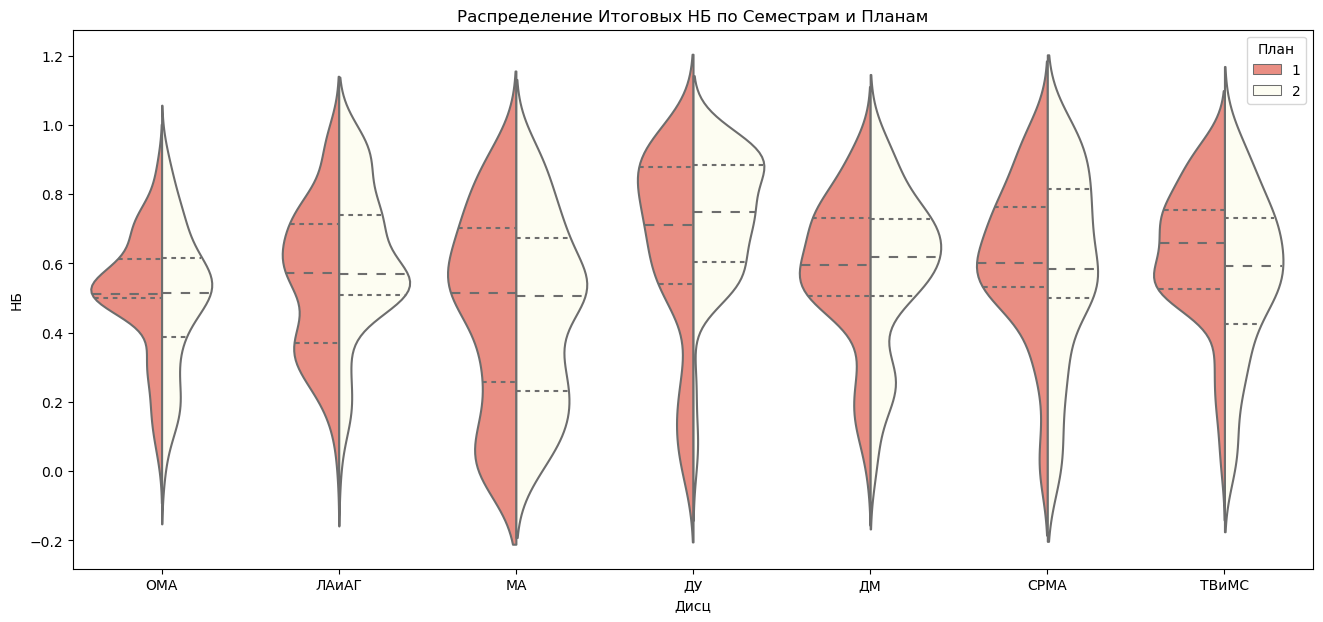

In [27]:
plt.figure(figsize=(16, 7))
sns.violinplot(x='Дисц', y='НБ', hue='План', data=final_df, split=True, inner='quart',
               order=DISC_TUPLE,
               palette={1: 'salmon', 2: 'ivory'},
               density_norm='count'
)
plt.title('Распределение Итоговых НБ по Семестрам и Планам')
plt.show()

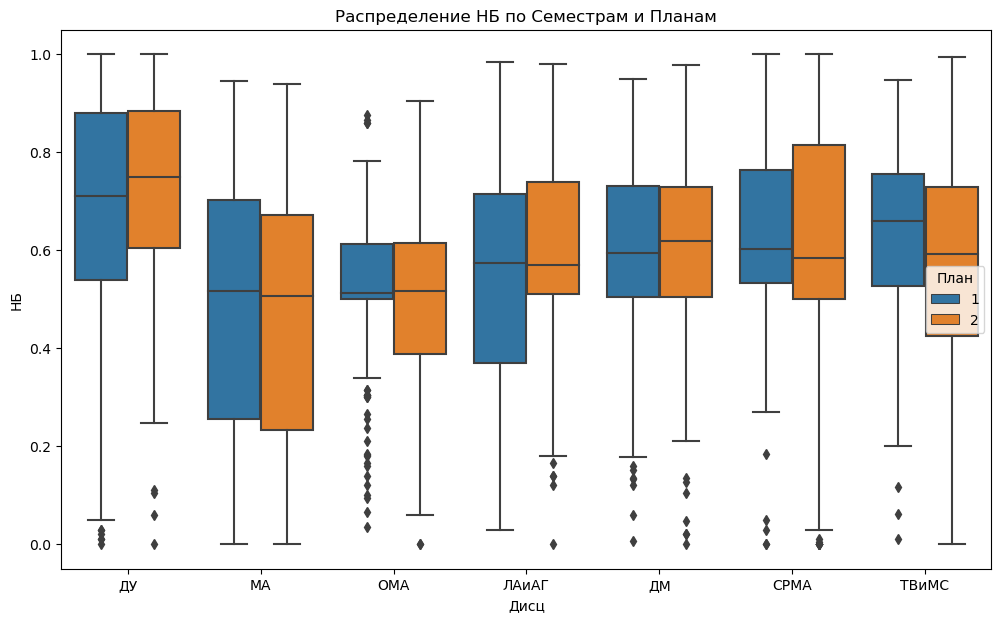

In [28]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Дисц', y='НБ', hue='План', data=final_df)
plt.title('Распределение НБ по Семестрам и Планам')
plt.show()

---
## 3. Расчет ПКБП

TODO: разжевать про ПКБП\

ПКБП (поправочный коэффициент базовой подготоки): ...

In [29]:
final_df.to_excel('final_df.xlsx', index=False)

In [53]:
# новый план
df = pd.read_excel("data\\Данные по Плану 1 ПИН\\Дисц 1 и 2 семестра  ПИН_31-36 22-23.xlsx", header=0)
OMA_res_1 = df[' оМА_итог'].dropna().tolist()
df2 = pd.read_excel("data\\Данные по Плану 2 ПИН\\ОМА ПИН-21-27 1 сем 23-24.xlsx", header=0)
OMA_res_2 = df2['Unnamed: 12'][4:].tolist()
# нормировка
OMA_res_2 = [x/100 for x in OMA_res_2]

In [61]:
SRMA_res = final_df.loc[final_df['Дисц'] == 'СРМА']
SRMA_res_1 = SRMA_res.loc[SRMA_res['План'] == 1, "НБ"].tolist()
SRMA_res_2 = SRMA_res.loc[SRMA_res['План'] == 2, "НБ"].tolist()


len(OMA_res_1)

143